# 🛒 E-commerce Product Recommendation System
## Notebook 5: Evaluation — Precision@K, Recall@K, NDCG@K

**Goal:** Measure recommendation quality using proper ranking metrics.

### Why not accuracy?
Accuracy is meaningless for recommendation systems. A model predicting all negatives achieves 83% accuracy (given 1:5 ratio) with zero recommendation value.  
We care about: **are the right products ranked at the top?**

### Steps:
1. Load predictions
2. Compute Precision@K, Recall@K, NDCG@K
3. Compare XGBoost vs Popularity Baseline
4. Top-K recommendations per customer
5. Final project summary

---
## 1. Imports + Load Predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load test predictions from Notebook 04
test_data = pd.read_csv('../data/test_predictions.csv')

# Load popularity baseline (from Notebook 01)
popularity = pd.read_csv('../data/popularity.csv')

print(f'Test predictions shape: {test_data.shape}')
print(f'Columns: {test_data.columns.tolist()}')
print(f'\nLabel distribution:')
print(test_data['label'].value_counts())

Test predictions shape: (230603, 15)
Columns: ['CustomerID', 'Description', 'label', 'LastPurchaseDate', 'Frequency', 'Monetary', 'Recency', 'TotalUnitsSold', 'UniqueBuyers', 'AvgTransactionValue', 'Category', 'CategoryAffinity', 'CategoryCount', 'TimesBought', 'pred_proba']

Label distribution:
0    192181
1     38422
Name: label, dtype: int64


---
## 2. Ranking Metrics — Theory

For each customer we rank all candidate products by predicted probability.  
We then check — are the products they actually bought in the top K?

| Metric | Question | Formula |
|---|---|---|
| **Precision@K** | Of the top-K products we recommended, what fraction did they actually buy? | relevant_in_topK / K |
| **Recall@K** | Of all products they actually bought, what fraction appeared in our top-K? | relevant_in_topK / total_relevant |
| **NDCG@K** | Are the most relevant products ranked highest within the top-K? | Penalises relevant items ranked lower |

**Analogy:**  
You recommend 10 movies to a friend. They liked 3 of them.  
- Precision@10 = 3/10 = 0.30 (30% of your recommendations were relevant)  
- Recall@10 = 3/5 = 0.60 (you found 3 of their 5 favourite movies)  
- NDCG@10 = higher if their favourite movie is ranked #1 vs #10

In [2]:
# ── Metric Functions ───────────────────────────────────────────────────

def precision_at_k(relevant, recommended, k):
    """Fraction of top-K recommendations that are relevant."""
    top_k = recommended[:k]
    hits  = len(set(top_k) & set(relevant))
    return hits / k


def recall_at_k(relevant, recommended, k):
    """Fraction of relevant items that appear in top-K recommendations."""
    if len(relevant) == 0:
        return 0.0
    top_k = recommended[:k]
    hits  = len(set(top_k) & set(relevant))
    return hits / len(relevant)


def dcg_at_k(relevant, recommended, k):
    """Discounted Cumulative Gain — rewards relevant items ranked higher."""
    top_k = recommended[:k]
    dcg   = 0.0
    for i, item in enumerate(top_k):
        if item in relevant:
            # log2(rank+1) — items at rank 1 contribute more than rank 10
            dcg += 1.0 / np.log2(i + 2)
    return dcg


def ndcg_at_k(relevant, recommended, k):
    """Normalised DCG — divides by ideal DCG (all relevant items ranked first)."""
    actual_dcg = dcg_at_k(relevant, recommended, k)
    # Ideal: all relevant items ranked at positions 1, 2, 3...
    ideal_dcg  = dcg_at_k(relevant, list(relevant)[:k], k)
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg


print('Metric functions defined: precision_at_k, recall_at_k, ndcg_at_k ✅')

Metric functions defined: precision_at_k, recall_at_k, ndcg_at_k ✅


---
## 3. Evaluate XGBoost — Precision@K, Recall@K, NDCG@K

For each customer:
1. Rank all candidate products by `pred_proba` (descending)
2. Get the products they actually bought (label=1) → ground truth
3. Compute metrics at K = 5, 10, 20

In [3]:
def evaluate_model(df, pred_col, k_values=[5, 10, 20]):
    """
    Evaluate a recommendation model using ranking metrics.
    
    Args:
        df:       DataFrame with CustomerID, Description, label, pred_col
        pred_col: column name with prediction scores
        k_values: list of K values to evaluate at
    
    Returns:
        results_df: per-customer metrics
        summary:    mean metrics across all customers
    """
    results = []
    
    for customer_id, group in df.groupby('CustomerID'):
        # Ground truth: products this customer actually bought
        relevant    = set(group[group['label'] == 1]['Description'].values)
        
        # Ranked list: sort all candidates by predicted probability
        ranked      = group.sort_values(pred_col, ascending=False)['Description'].values
        
        row = {'CustomerID': customer_id, 'n_relevant': len(relevant)}
        
        for k in k_values:
            row[f'Precision@{k}'] = precision_at_k(relevant, ranked, k)
            row[f'Recall@{k}']    = recall_at_k(relevant, ranked, k)
            row[f'NDCG@{k}']      = ndcg_at_k(relevant, ranked, k)
        
        results.append(row)
    
    results_df = pd.DataFrame(results)
    
    # Mean across all customers
    metric_cols = [c for c in results_df.columns if c not in ['CustomerID', 'n_relevant']]
    summary     = results_df[metric_cols].mean().round(4)
    
    return results_df, summary


print('Evaluating XGBoost model...')
xgb_results, xgb_summary = evaluate_model(test_data, pred_col='pred_proba')

print('\nXGBoost Results:')
print(xgb_summary.to_string())

Evaluating XGBoost model...

XGBoost Results:
Precision@5     0.9347
Recall@5        0.3404
NDCG@5          0.9713
Precision@10    0.8729
Recall@10       0.5429
NDCG@10         0.9689
Precision@20    0.7412
Recall@20       0.7636
NDCG@20         0.9697


---
## 4. Popularity Baseline

Always compare your model against a simple baseline.  
The popularity baseline recommends the globally most popular products to every customer — no personalisation.

**If XGBoost can't beat this → the personalisation signal is weak.**

In [5]:
print(popularity.columns.tolist())
print(popularity.head())

['Description', 'TotalUnitsSold']
                          Description  TotalUnitsSold
0   WORLD WAR 2 GLIDERS ASSTD DESIGNS           46870
1             JUMBO BAG RED RETROSPOT           35703
2  WHITE HANGING HEART T LIGHT HOLDER           29985
3                      POPCORN HOLDER           29380
4       ASSORTED COLOUR BIRD ORNAMENT           28140


In [6]:
import re

# Normalise popularity descriptions to match test_data
popularity['Description'] = popularity['Description'].apply(
    lambda x: re.sub(r'[^\w\s]', ' ', str(x))
).str.strip().str.upper()

# Sort by TotalUnitsSold (not UniqueBuyers — not in popularity.csv)
popularity = popularity.sort_values('TotalUnitsSold', ascending=False).reset_index(drop=True)
popularity['popularity_score'] = 1 / (popularity.index + 1)  # 1/rank

# Merge popularity score onto test_data
test_data_pop = test_data.merge(
    popularity[['Description', 'popularity_score']],
    on='Description', how='left'
)
test_data_pop['popularity_score'] = test_data_pop['popularity_score'].fillna(0)

print('Evaluating popularity baseline...')
pop_results, pop_summary = evaluate_model(test_data_pop, pred_col='popularity_score')

print('\nPopularity Baseline Results:')
print(pop_summary.to_string())

Evaluating popularity baseline...

Popularity Baseline Results:
Precision@5     0.5134
Recall@5        0.1994
NDCG@5          0.5593
Precision@10    0.4697
Recall@10       0.3241
NDCG@10         0.5502
Precision@20    0.4117
Recall@20       0.4952
NDCG@20         0.5704


---
## 5. XGBoost vs Popularity Baseline — Head to Head

In [7]:
# ── Comparison Table ───────────────────────────────────────────────────
comparison = pd.DataFrame({
    'XGBoost':    xgb_summary,
    'Popularity': pop_summary
})
comparison['Improvement'] = ((comparison['XGBoost'] - comparison['Popularity']) / 
                              comparison['Popularity'] * 100).round(1).astype(str) + '%'

print('XGBoost vs Popularity Baseline:')
print(comparison.to_string())

XGBoost vs Popularity Baseline:
              XGBoost  Popularity Improvement
Precision@5    0.9347      0.5134       82.1%
Recall@5       0.3404      0.1994       70.7%
NDCG@5         0.9713      0.5593       73.7%
Precision@10   0.8729      0.4697       85.8%
Recall@10      0.5429      0.3241       67.5%
NDCG@10        0.9689      0.5502       76.1%
Precision@20   0.7412      0.4117       80.0%
Recall@20      0.7636      0.4952       54.2%
NDCG@20        0.9697      0.5704       70.0%


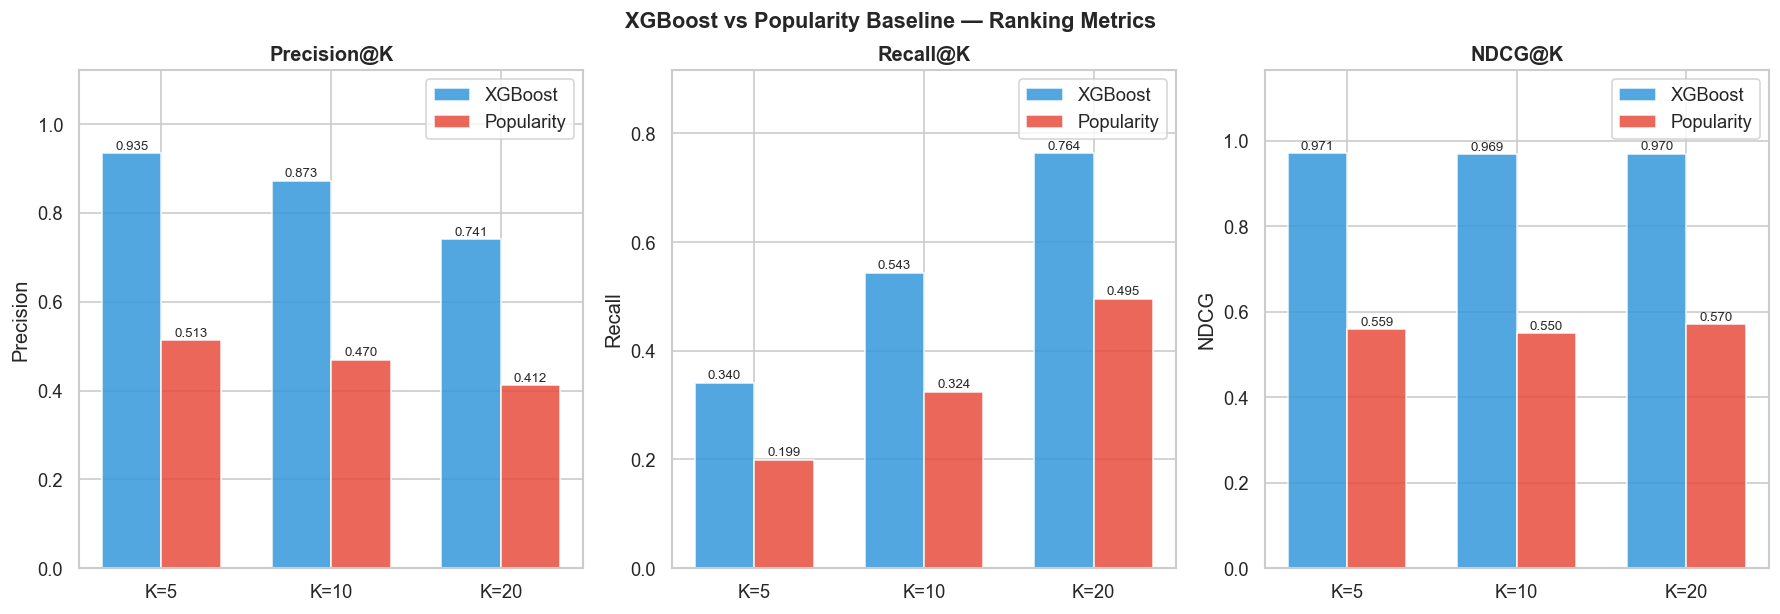

In [8]:
# ── Comparison Visualisation ───────────────────────────────────────────
k_values  = [5, 10, 20]
metrics   = ['Precision', 'Recall', 'NDCG']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    xgb_vals = [xgb_summary[f'{metric}@{k}'] for k in k_values]
    pop_vals = [pop_summary[f'{metric}@{k}'] for k in k_values]
    
    x = np.arange(len(k_values))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, xgb_vals, width, label='XGBoost',    color='#3498DB', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, pop_vals,  width, label='Popularity', color='#E74C3C', alpha=0.85, edgecolor='white')
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_title(f'{metric}@K', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f'K={k}' for k in k_values])
    ax.set_ylabel(metric)
    ax.legend()
    ax.set_ylim(0, max(max(xgb_vals), max(pop_vals)) * 1.2)

plt.suptitle('XGBoost vs Popularity Baseline — Ranking Metrics', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', bbox_inches='tight')
plt.show()

---
## 6. Metric Distribution Across Customers

Mean metrics can hide a lot. Let's look at the distribution of NDCG@10 per customer — are most customers well-served, or are a few customers pulling the mean up?

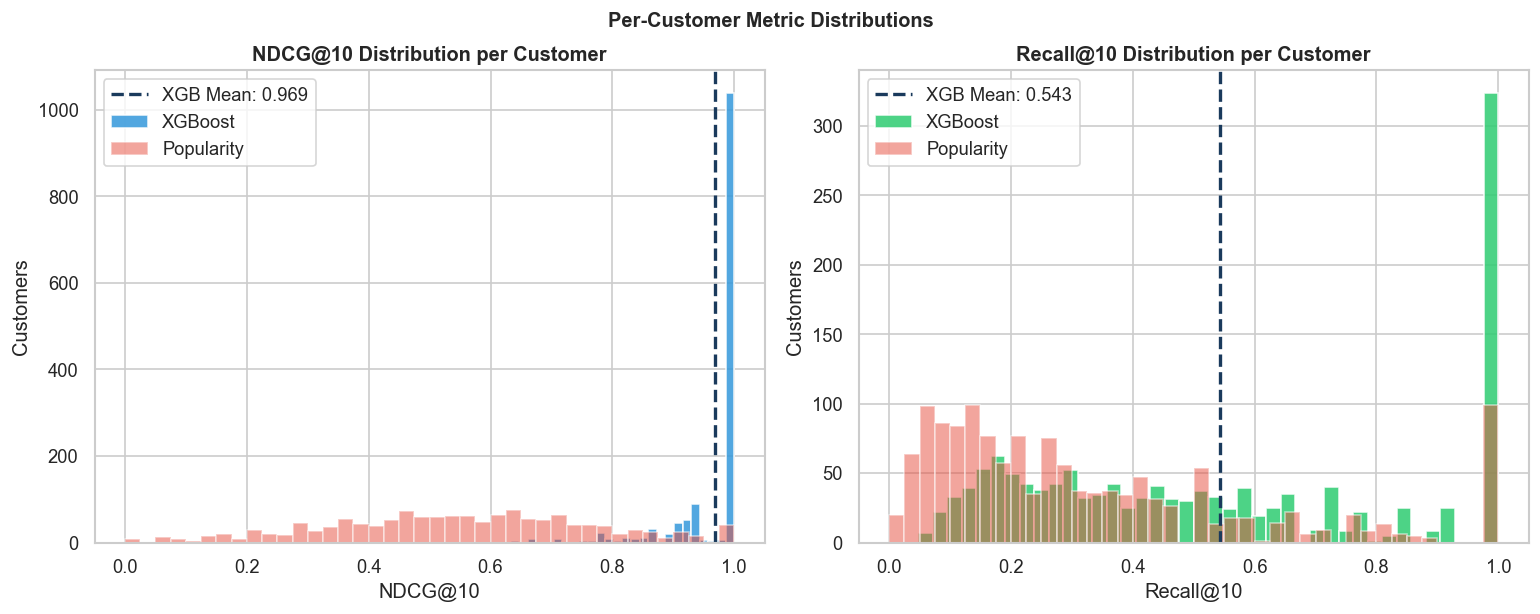

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# NDCG@10 distribution
axes[0].hist(xgb_results['NDCG@10'], bins=40, color='#3498DB', alpha=0.85, edgecolor='white', label='XGBoost')
axes[0].hist(pop_results['NDCG@10'],  bins=40, color='#E74C3C', alpha=0.5,  edgecolor='white', label='Popularity')
axes[0].axvline(xgb_results['NDCG@10'].mean(), color='#1A3A5C', linestyle='--', linewidth=2,
                label=f'XGB Mean: {xgb_results["NDCG@10"].mean():.3f}')
axes[0].set_title('NDCG@10 Distribution per Customer', fontweight='bold')
axes[0].set_xlabel('NDCG@10')
axes[0].set_ylabel('Customers')
axes[0].legend()

# Recall@10 distribution
axes[1].hist(xgb_results['Recall@10'], bins=40, color='#2ECC71', alpha=0.85, edgecolor='white', label='XGBoost')
axes[1].hist(pop_results['Recall@10'],  bins=40, color='#E74C3C', alpha=0.5,  edgecolor='white', label='Popularity')
axes[1].axvline(xgb_results['Recall@10'].mean(), color='#1A3A5C', linestyle='--', linewidth=2,
                label=f'XGB Mean: {xgb_results["Recall@10"].mean():.3f}')
axes[1].set_title('Recall@10 Distribution per Customer', fontweight='bold')
axes[1].set_xlabel('Recall@10')
axes[1].set_ylabel('Customers')
axes[1].legend()

plt.suptitle('Per-Customer Metric Distributions', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/metric_distributions.png', bbox_inches='tight')
plt.show()

---
## 7. Top-K Recommendations for Sample Customers

The concrete output of the system — what products does the model actually recommend?

In [10]:
def get_top_k_recommendations(customer_id, df, k=10):
    """
    Get top-K product recommendations for a specific customer.
    Shows predicted probability and whether they actually bought it.
    """
    customer_df = df[df['CustomerID'] == customer_id].copy()
    
    if customer_df.empty:
        print(f'Customer {customer_id} not found in test data')
        return
    
    # Rank by predicted probability
    top_k = (customer_df
             .sort_values('pred_proba', ascending=False)
             .head(k)[['Description', 'pred_proba', 'label']]
             .rename(columns={'label': 'actually_bought', 'pred_proba': 'score'})
             .reset_index(drop=True))
    
    top_k.index += 1  # rank starts at 1
    top_k['actually_bought'] = top_k['actually_bought'].map({1: '✅ Yes', 0: '❌ No'})
    top_k['score'] = top_k['score'].round(4)
    
    print(f'Top-{k} recommendations for Customer {customer_id}:')
    print(top_k.to_string())
    return top_k


# Show recommendations for 2 sample customers
sample_customers = test_data['CustomerID'].unique()[:2]

for cid in sample_customers:
    get_top_k_recommendations(cid, test_data, k=10)
    print()

Top-10 recommendations for Customer 12347:
                          Description   score actually_bought
1            REGENCY CAKESTAND 3 TIER  0.9986           ✅ Yes
2            ALARM CLOCK BAKELIKE RED  0.9984           ✅ Yes
3   VINTAGE HEADS AND TAILS CARD GAME  0.9984           ✅ Yes
4          ALARM CLOCK BAKELIKE GREEN  0.9984           ✅ Yes
5         60 TEATIME FAIRY CAKE CASES  0.9983           ✅ Yes
6           ALARM CLOCK BAKELIKE PINK  0.9983           ✅ Yes
7      72 SWEETHEART FAIRY CAKE CASES  0.9983           ✅ Yes
8                  RABBIT NIGHT LIGHT  0.9982           ✅ Yes
9              WOODLAND CHARLOTTE BAG  0.9982           ✅ Yes
10    ROSES REGENCY TEACUP AND SAUCER  0.9981           ✅ Yes

Top-10 recommendations for Customer 12352:
                         Description   score actually_bought
1               IVORY KITCHEN SCALES  0.9981           ✅ Yes
2                            POSTAGE  0.9981           ✅ Yes
3    CHILDS BREAKFAST SET DOLLY GIRL  0.9973    

---
## 8. Final Project Summary

In [11]:
print('=' * 60)
print('    XGBOOST RECOMMENDATION SYSTEM — FINAL SUMMARY')
print('=' * 60)
print()
print('DATASET')
print(f'  Raw transactions:     541,909')
print(f'  Clean transactions:   270,848')
print(f'  Customers:            3,936')
print(f'  Products:             3,779')
print(f'  Matrix sparsity:      97.6%')
print()
print('MODELLING')
print(f'  Algorithm:            XGBoost (binary classification)')
print(f'  Negative sampling:    1:5 ratio (random)')
print(f'  Train samples:        {len(pd.read_csv("../data/train_data.csv")):,}')
print(f'  Test samples:         {len(test_data):,}')
print(f'  Hyperparameter tuning: Optuna (Bayesian, 30 trials)')
print()
print('EVALUATION — XGBoost vs Popularity Baseline')
for metric in ['Precision@10', 'Recall@10', 'NDCG@10']:
    xgb_val = xgb_summary[metric]
    pop_val = pop_summary[metric]
    delta   = xgb_val - pop_val
    sign    = '+' if delta >= 0 else ''
    print(f'  {metric:<15} XGBoost={xgb_val:.4f}  Popularity={pop_val:.4f}  ({sign}{delta:.4f})')
print()
print('FEATURES')
print('  User:           Recency, Frequency, Monetary')
print('  Product:        TotalUnitsSold, UniqueBuyers, AvgTransactionValue, Category')
print('  Interaction:    CategoryAffinity, CategoryCount, TimesBought')
print()
print('=' * 60)

    XGBOOST RECOMMENDATION SYSTEM — FINAL SUMMARY

DATASET
  Raw transactions:     541,909
  Clean transactions:   270,848
  Customers:            3,936
  Products:             3,779
  Matrix sparsity:      97.6%

MODELLING
  Algorithm:            XGBoost (binary classification)
  Negative sampling:    1:5 ratio (random)
  Train samples:        1,025,731
  Test samples:         230,603
  Hyperparameter tuning: Optuna (Bayesian, 30 trials)

EVALUATION — XGBoost vs Popularity Baseline
  Precision@10    XGBoost=0.8729  Popularity=0.4697  (+0.4032)
  Recall@10       XGBoost=0.5429  Popularity=0.3241  (+0.2188)
  NDCG@10         XGBoost=0.9689  Popularity=0.5502  (+0.4187)

FEATURES
  User:           Recency, Frequency, Monetary
  Product:        TotalUnitsSold, UniqueBuyers, AvgTransactionValue, Category
  Interaction:    CategoryAffinity, CategoryCount, TimesBought

